In [ ]:
from model import MLC, describe_model
import datasets as dat
from datasets import Lang, LetterStringDataset

import torch
from torch.utils.data import DataLoader

import string
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from evaluate import predict
# data = pd.read_csv("https://raw.githubusercontent.com/marthaflinderslewis/counterfactual_analogy/refs/heads/main/data/data.csv")
# data.head()

In [ ]:
D_train = LetterStringDataset(data_dir="data", mode="train")
train_dataloader = DataLoader(D_train,batch_size=5,collate_fn=lambda x:dat.get_mlc_batch(x,D_train.langs),
                                    shuffle=True)

In [3]:
sample_batch = next(iter(train_dataloader))
print("Input to the model:")
print(sample_batch["xq_context"][0])
D_train.pprint(sample_batch)

Input to the model:
['SOS', 'a', 'b', 'c', 's', 'z', 'j', 'm', 'f', 'w', 'n', 'k', 'd', 'o', 'q', 'g', 'e', 'u', 'h', 'p', 't', 'v', 'r', 'x', 'i', 'y', 'l', 'SOS', 'r', 'x', 'i', 'y', 'IO', 'r', 'x', 'i', 'l', 'SOS', 'q', 'g', 'e', 'u']

Problems:

abcszjmfwnkdoqgeuhptvrxiyl
rxiy -> rxil
qgeu -> ? (qgeh)

abcszjmfwnkdoqgeuhptvrxiyl
dko -> kdo
eqgo -> ? (oqge)

abcdefgpijklmnohqrstuvwxyz
qrss -> qrs
tuvwwxyz -> ? (tuvwxyz)

abcszjmfwnkdoqgeuhptvrxiyl
kdoq -> kdoqg
vrxiy -> ? (vrxiyl)

abcdefgpijklmnohqrstuvwxyz
efgpij -> dfgpij
klmnoh -> ? (jlmnoh)

abwdgfihrqkljncpoestuvmxyz
jncc -> jnc
jncppo -> ? (jncpo)

hbcdlfgsijkemnopqratuvwxyz
pqrat -> pqrau
cdlf -> ? (cdlg)

abcdefgpijklmnohqrstuvwxyz
kji -> ijk
honq -> ? (nohq)

abcdefgpijklmnohqrstuvwxyz
rstuv -> rstuvw
cdefgp -> ? (cdefgpi)

abcdefghijklmnopqrstuvwxyz
hgfij -> fghij
stxvwu -> ? (stuvwx)

abcdefgpijklmnohqrstuvwxyz
fgpij -> egpij
ijkl -> ? (pjkl)

abcdefgpijklmnohqrstuvwxyz
bcdeff -> bcdef
ggpi -> ? (gpi)

hbcdlfgsijkemnopqr

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

alphabet = list(string.ascii_lowercase)
standard_language = Lang(alphabet)

in_size = len(D_train.langs["input"].index2symbol)
out_size = len(D_train.langs["output"].index2symbol)
pad_in = D_train.langs["input"].PAD_idx
pad_out = D_train.langs["output"].PAD_idx

net = MLC(
    hidden_size=128, 
    input_size=in_size, 
    output_size=out_size, 
    PAD_idx_input=pad_in, 
    PAD_idx_output=pad_out
    )
net = net.to(device=DEVICE)

describe_model(net)        


MLC specs:
 nparams= 1797150
 nlayers_encoder= 5
 nlayers_decoder= 3
 nhead= 8
 hidden_size= 128
 dim_feedforward= 512
 act_feedforward= gelu
 dropout= 0.1
 



In [6]:
predictions = predict(
    batch=sample_batch,
    net=net, 
    langs=D_train.langs,
    max_length=20,
    eval_type="sample"
)
for pred in predictions:
    print("".join(pred))

c:\Users\phili\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\functional.py:5109: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


atwykfjaovghepwafzjd
uuodduswdrywfnjktnPADe
qtuPADIOfIOareeblcevyxnIO
SOSukgdzmSOSxempmvzyimcg
gniuefldzmjnksazujeo
jdPADzkPADjjyzpgcbdxxbIOs
esxkydduzSOSyhpPADypuaPADd
dzvlyzlvjmmcuPADawkbdSOS
gyqbPADdwmngzuPADyzaiqwr
jfyndwmh
yuvajSOSberuhnxgIOjvvaSOS
rkdPADc
wfdyxdtbmzxjassdbIOIOn
diujeuuumnrbvbtnxsxj
nhoIOyyeIOorcrevrmtcIOSOS
ctrcyzlnxgIOuPADpmvjm
sPADzauzvcddjqIOjgmjrlk
yphxiifxuovavuyglhwn
jgaxduyifylyiwadjyde
lnrjvtPADtjeotPADgim
PADzfyxndzPADhudmfdedxor
psmsycqfysdtgzcdkwly
grbooxzenmSOSIOudmmIOgrr
vivjncIOpxIOIOwmbvjgczt
ymyfj
ededomnyyigduIOmiqkmr
mxkjgwvd
uufuIOyzztyamiydlhzem
ejpyjixdSOSf
dSOSdjargzopumhhxayihu
qcnoucpztydsrSOSqdvrdl
zjeqIOemjnyIOdvvjzjsrd
j
qsndxIOpSOSxlvpimreyPADIOd
yslnrzdjcmkgydyuyyhj
vmmjjmjmkb
ccbydzzjyPADjruIOhdrIOfi
xcuxzySOSIOfznPADlIOusbezj
yPADwuosejirnkfkisaisk
erdjadeuoou
eqtmdnzivblvirldPADPADzv
fncPADvyvkclaqabmgSOSmyd
rczvduaenyuIOydedjnyv
kuSOSddurhIOkSOSrqduhffzPAD
xludccyyIOddIOuy
kkdmldxseancxdgdyPADuf
pvIOjrrqcdemryvrSOSipIOg
tIOPADybdy

In [8]:
example_context = ["i","j","k","l", "SOS", "a","b","c","d","IO","a","b","c","e","SOS"] + alphabet + ["EOS"] 
example_context_padded = example_context + ["PAD" for _ in range(127-len(example_context))]
batch = dict()
batch["xq_context_padded"] = D_train.langs["input"].symbols_to_tensor(example_context_padded).unsqueeze(0)
batch["yq"] = [["i","j","k","m"]]
m = len(batch['yq']) # b*nq
z_padded = torch.tensor([D_train.langs["input"].symbol2index["SOS"]]*m) # b*nq length tensor
z_padded = z_padded.unsqueeze(0) # [b*nq x 1] tensor
z_padded = z_padded.to(device=DEVICE)
z_padded
# get predictions from the model
forward_pass = net(z_padded, batch)
forward_pass

tensor([[[-1.0523,  0.0362, -0.0219,  1.0368,  0.5023,  0.4707,  0.1490,
          -0.2684, -0.4028,  0.6200, -0.2402, -0.5748, -0.1073,  0.1210,
          -0.4847, -0.9347, -0.9503,  1.0586, -0.2314, -0.1859,  0.8147,
           0.1186,  0.0506, -0.1592,  0.9517,  0.1569, -0.7761, -0.5524,
           0.4877, -0.3882]]], grad_fn=<ViewBackward0>)

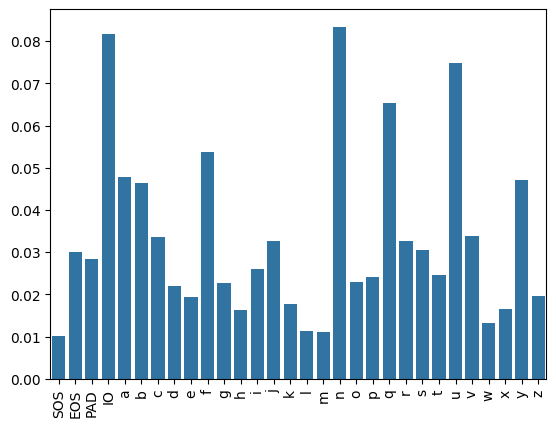

In [9]:
out_probs = torch.nn.functional.softmax(forward_pass, dim=2).detach().numpy().squeeze()
labels = D_train.langs["output"].index2symbol.values()
_ = sns.barplot(x=labels, y=out_probs)
_ = plt.xticks(rotation=90)